# 03 - HHL and Its Role in Quantum Machine Learning

The Harrow-Hassidim-Lloyd (HHL) algorithm is a quantum algorithm for linear systems:

$$
A x = b.
$$

In classical notation, the solution is

$$
x = A^{-1}b.
$$

In HHL, the input vector is encoded as a quantum state \(|b\rangle\), and the output is a quantum state proportional to the solution:

$$
|x\rangle = \frac{A^{-1}|b\rangle}{\|A^{-1}|b\rangle\|}.
$$

This matters for QML because many learning algorithms reduce to solving linear systems, for example least squares, kernel ridge regression, Gaussian-process-style prediction, and some least-squares support vector machines.


## Spectral idea

Suppose \(A\) is Hermitian and has eigendecomposition

$$
A = \sum_j \lambda_j |u_j\rangle\langle u_j|.
$$

Expand the input state in the eigenbasis:

$$
|b\rangle = \sum_j \beta_j |u_j\rangle.
$$

Then

$$
A^{-1}|b\rangle = \sum_j \frac{\beta_j}{\lambda_j}|u_j\rangle.
$$

HHL implements this transformation coherently. At a high level:

1. prepare \(|b\rangle\),
2. use quantum phase estimation to write eigenvalue information into a register,
3. rotate an ancilla by an amount proportional to \(1/\lambda_j\),
4. uncompute the phase register,
5. postselect or amplitude-amplify the ancilla success state.


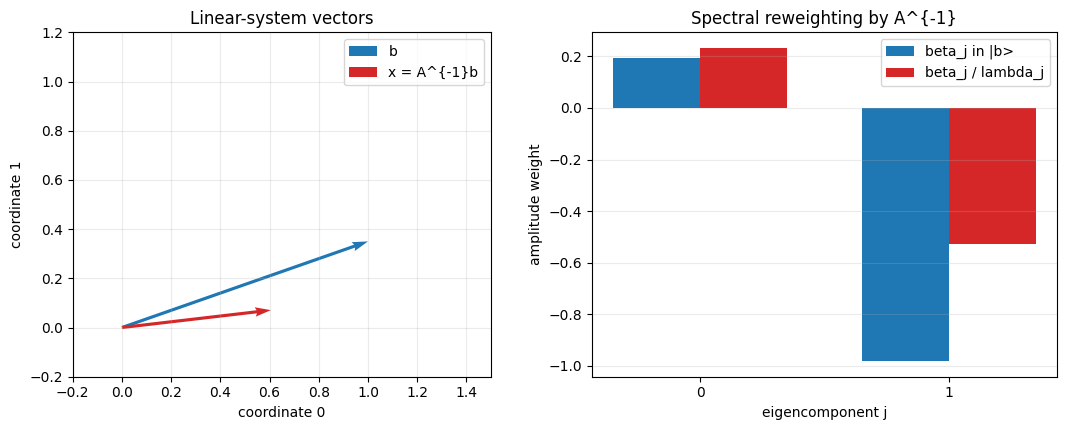

A =
[[1.6  0.45]
 [0.45 1.1 ]]
b = [1.   0.35]
classical solution x = [0.605 0.071]
eigenvalues = [0.835 1.865]
normalized HHL-style solution state = [0.993 0.116]


In [1]:
# Pseudo-code:
#   1. solve a small linear system classically
#   2. decompose A into eigenvalues and eigenvectors
#   3. show inverse-eigenvalue reweighting
#   4. plot vector geometry and spectral weights

# Classical linear-system geometry for a two-dimensional example.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[1.6, 0.45], [0.45, 1.1]])
b = np.array([1.0, 0.35])
# Initialize or update trainable model parameters.
x = np.linalg.solve(A, b)
# Solve the linear system for model coefficients.

eigenvalues, eigenvectors = np.linalg.eigh(A)
# Diagonalize the matrix to inspect spectral behavior.
beta = eigenvectors.T @ (b / np.linalg.norm(b))
inverse_weighted = beta / eigenvalues
x_state = eigenvectors @ inverse_weighted
# Store quantum-state amplitudes for overlap calculations.
x_state = x_state / np.linalg.norm(x_state)
# Store quantum-state amplitudes for overlap calculations.

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

origin = np.zeros(2)
axes[0].quiver(*origin, *b, angles="xy", scale_units="xy", scale=1, color="tab:blue", label="b")
axes[0].quiver(*origin, *x, angles="xy", scale_units="xy", scale=1, color="tab:red", label="x = A^{-1}b")
axes[0].set_xlim(-0.2, 1.5)
axes[0].set_ylim(-0.2, 1.2)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Linear-system vectors")
axes[0].set_xlabel("coordinate 0")
axes[0].set_ylabel("coordinate 1")
axes[0].grid(alpha=0.25)
axes[0].legend()

width = 0.35
positions = np.arange(len(eigenvalues))
axes[1].bar(positions - width / 2, beta, width=width, label="beta_j in |b>", color="tab:blue")
axes[1].bar(positions + width / 2, inverse_weighted, width=width, label="beta_j / lambda_j", color="tab:red")
axes[1].set_title("Spectral reweighting by A^{-1}")
axes[1].set_xlabel("eigencomponent j")
axes[1].set_ylabel("amplitude weight")
axes[1].set_xticks(positions)
axes[1].grid(alpha=0.25, axis="y")
axes[1].legend()

plt.tight_layout()
plt.show()

print("A =")
print(A)
print("b =", np.round(b, 3))
print("classical solution x =", np.round(x, 3))
print("eigenvalues =", np.round(eigenvalues, 3))
print("normalized HHL-style solution state =", np.round(x_state, 3))


## A minimal HHL-style state transformation

Full HHL uses phase estimation to learn eigenvalues in superposition. For a minimal implementable example, use a diagonal matrix whose eigenvectors are already computational basis states:

$$
A =
\begin{bmatrix}
1 & 0 \\\\
0 & 2
\end{bmatrix}.
$$

If

$$
|b\rangle = b_0|0\rangle + b_1|1\rangle,
$$

then

$$
A^{-1}|b\rangle = b_0|0\rangle + \frac{b_1}{2}|1\rangle.
$$

The HHL controlled-rotation step attaches an ancilla:

$$
|j\rangle|0\rangle
\mapsto
|j\rangle
\left(
\sqrt{1-\frac{C^2}{\lambda_j^2}}|0\rangle
+
\frac{C}{\lambda_j}|1\rangle
\right),
$$

where \(C \le \min_j \lambda_j\). Postselecting ancilla \(|1\rangle\) leaves amplitudes proportional to \(b_j/\lambda_j\).


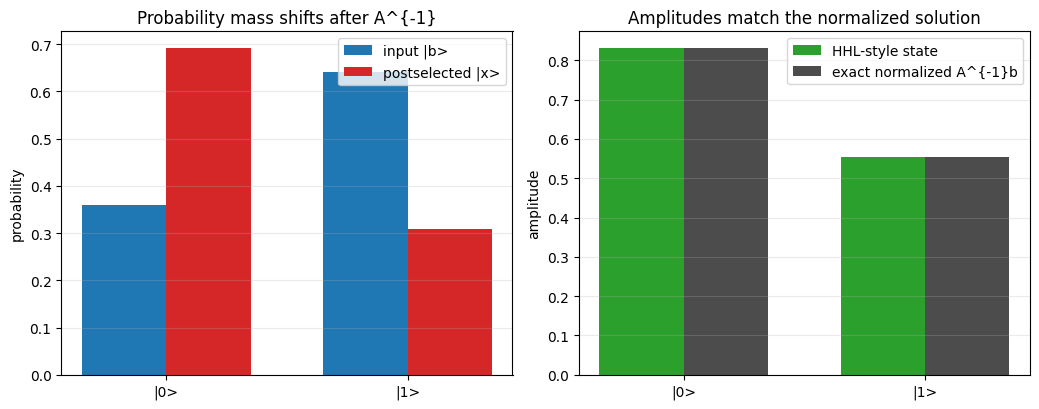

success probability: 0.2925
postselected state: [0.8321 0.5547]
exact solution state: [0.8321 0.5547]
state error norm: 1.5700924586837752e-16


In [2]:
# Pseudo-code:
#   1. prepare a diagonal two-eigenvalue system
#   2. simulate controlled inverse-eigenvalue rotation
#   3. postselect the success ancilla
#   4. compare with exact normalized solution

# Minimal HHL-style controlled inverse-eigenvalue step for diagonal A.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

lambdas = np.array([1.0, 2.0])
b = np.array([0.6, 0.8])
# Initialize or update trainable model parameters.
b = b / np.linalg.norm(b)
# Initialize or update trainable model parameters.
C = 0.75

# State order is |system, ancilla>: |00>, |01>, |10>, |11>.
state = np.zeros(4, dtype=complex)
# Store quantum-state amplitudes for overlap calculations.
state[0] = b[0]
# Store quantum-state amplitudes for overlap calculations.
state[2] = b[1]
# Store quantum-state amplitudes for overlap calculations.

after_rotation = np.zeros(4, dtype=complex)
for system_value, lambda_value in enumerate(lambdas):
    # Iterate through this part of the algorithm.
    amplitude = b[system_value]
    ancilla_one = C / lambda_value
    ancilla_zero = np.sqrt(1.0 - ancilla_one**2)
    after_rotation[2 * system_value + 0] = amplitude * ancilla_zero
    after_rotation[2 * system_value + 1] = amplitude * ancilla_one

success_probability = np.sum(np.abs(after_rotation[[1, 3]]) ** 2)
# Compute model outputs for the current data.
postselected_system = np.array([after_rotation[1], after_rotation[3]]) / np.sqrt(success_probability)

exact_solution_state = (b / lambdas)
# Store quantum-state amplitudes for overlap calculations.
exact_solution_state = exact_solution_state / np.linalg.norm(exact_solution_state)
# Store quantum-state amplitudes for overlap calculations.

labels = ["|0>", "|1>"]
x = np.arange(2)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

axes[0].bar(x - width / 2, np.abs(b) ** 2, width=width, label="input |b>", color="tab:blue")
axes[0].bar(x + width / 2, np.abs(postselected_system) ** 2, width=width, label="postselected |x>", color="tab:red")
axes[0].set_title("Probability mass shifts after A^{-1}")
axes[0].set_xticks(x, labels)
axes[0].set_ylabel("probability")
axes[0].grid(alpha=0.25, axis="y")
axes[0].legend()

axes[1].bar(x - width / 2, np.real(postselected_system), width=width, label="HHL-style state", color="tab:green")
axes[1].bar(x + width / 2, exact_solution_state, width=width, label="exact normalized A^{-1}b", color="black", alpha=0.7)
axes[1].set_title("Amplitudes match the normalized solution")
axes[1].set_xticks(x, labels)
axes[1].set_ylabel("amplitude")
axes[1].grid(alpha=0.25, axis="y")
axes[1].legend()

plt.tight_layout()
plt.show()

print("success probability:", round(float(success_probability), 4))
print("postselected state:", np.round(postselected_system.real, 4))
print("exact solution state:", np.round(exact_solution_state, 4))
print("state error norm:", np.linalg.norm(postselected_system.real - exact_solution_state))


## Where HHL appears in QML

Kernel ridge regression and least-squares classifiers solve systems of the form

$$
(K+\lambda I)\alpha = y,
$$

where \(K\) is a kernel matrix. In QML, \(K\) may be a quantum kernel:

$$
K_{ij}=|\langle \phi(x_i)|\phi(x_j)\rangle|^2.
$$

The prediction for a new point is

$$
f(x)=\sum_i \alpha_i K(x_i,x).
$$

In principle, if \(K+\lambda I\) is sparse or efficiently block-encoded, well-conditioned, and if \(|y\rangle\) can be prepared efficiently, HHL can prepare a quantum state proportional to \(\alpha\):

$$
|\alpha\rangle \propto (K+\lambda I)^{-1}|y\rangle.
$$

That does not mean HHL prints all coefficients quickly. Reading out the full vector would destroy the advantage. The useful setting is estimating global quantities, overlaps, or predictions encoded as expectation values.


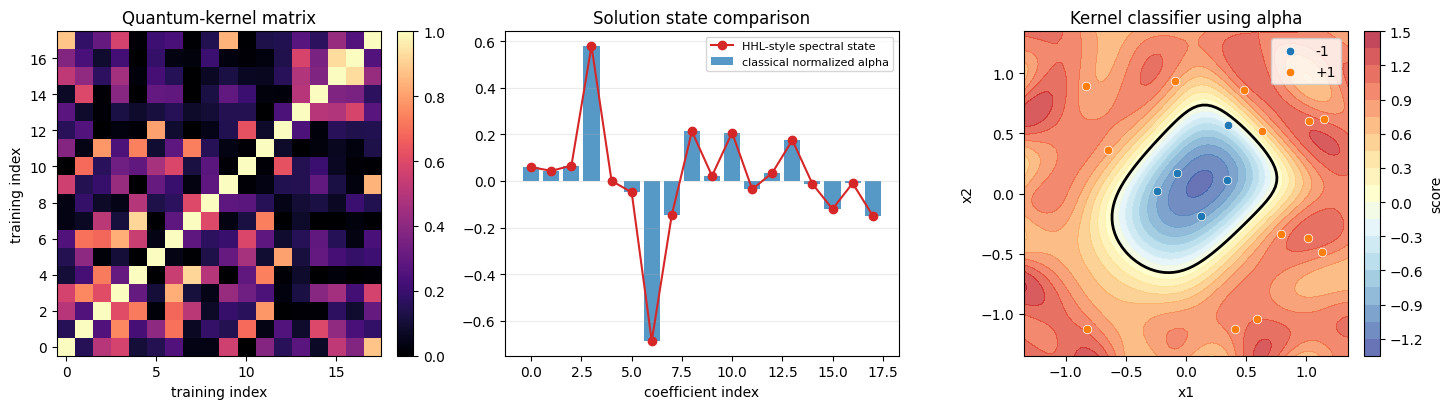

condition number of K + lambda I: 46.66
solution-state error norm: 1.6646647470402677e-15


In [3]:
# Pseudo-code:
#   1. build a quantum-inspired kernel matrix
#   2. solve kernel ridge coefficients
#   3. simulate HHL-style spectral inversion
#   4. plot kernel, solution state, and classifier

# Kernel-ridge classification and HHL-style spectral inversion of the same system.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(14)
n_train = 18
X = rng.uniform(-1.2, 1.2, size=(n_train, 2))
y = np.where(np.sum(X**2, axis=1) > 0.72**2, 1.0, -1.0)

def feature_state(features):
    # Define the reusable computation for this cell.
    x0, x1 = features
    state = np.array([
        np.cos(x0 / 2.0) * np.cos(x1 / 2.0),
        np.cos(x0 / 2.0) * np.sin(x1 / 2.0),
        np.sin(x0 / 2.0) * np.cos(x1 / 2.0),
        np.sin(x0 / 2.0) * np.sin(x1 / 2.0),
    ], dtype=complex)
    # Store quantum-state amplitudes for overlap calculations.
    phase = np.exp(1j * 0.7 * x0 * x1)
    state[3] *= phase
    # Store quantum-state amplitudes for overlap calculations.
    return state / np.linalg.norm(state)
    # Return the computed output for the caller.

states = np.array([feature_state(np.pi * x / 1.2) for x in X])
# Store quantum-state amplitudes for overlap calculations.
K = np.abs(states @ states.conj().T) ** 2
regularization = 0.12
system_matrix = K + regularization * np.eye(n_train)

alpha_classical = np.linalg.solve(system_matrix, y)
# Solve the linear system for model coefficients.

eigenvalues, eigenvectors = np.linalg.eigh(system_matrix)
# Diagonalize the matrix to inspect spectral behavior.
y_state = y / np.linalg.norm(y)
# Store quantum-state amplitudes for overlap calculations.
beta = eigenvectors.T @ y_state
alpha_state = eigenvectors @ (beta / eigenvalues)
# Store quantum-state amplitudes for overlap calculations.
alpha_state = alpha_state / np.linalg.norm(alpha_state)
# Store quantum-state amplitudes for overlap calculations.
alpha_classical_state = alpha_classical / np.linalg.norm(alpha_classical)
# Store quantum-state amplitudes for overlap calculations.

grid_x = np.linspace(-1.35, 1.35, 70)
grid_y = np.linspace(-1.35, 1.35, 70)
xx, yy = np.meshgrid(grid_x, grid_y)
grid = np.column_stack([xx.ravel(), yy.ravel()])
grid_states = np.array([feature_state(np.pi * x / 1.2) for x in grid])
# Store quantum-state amplitudes for overlap calculations.
K_grid = np.abs(states @ grid_states.conj().T) ** 2
# Compute pairwise similarities for the kernel method.
scores = alpha_classical @ K_grid
# Compute model outputs for the current data.
score_map = scores.reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

image = axes[0].imshow(K, origin="lower", cmap="magma", vmin=0, vmax=1)
axes[0].set_title("Quantum-kernel matrix")
axes[0].set_xlabel("training index")
axes[0].set_ylabel("training index")
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].bar(np.arange(n_train), alpha_classical_state, color="tab:blue", alpha=0.75, label="classical normalized alpha")
axes[1].plot(np.arange(n_train), alpha_state, color="tab:red", marker="o", linewidth=1.5, label="HHL-style spectral state")
axes[1].set_title("Solution state comparison")
axes[1].set_xlabel("coefficient index")
axes[1].grid(alpha=0.25, axis="y")
axes[1].legend(fontsize=8)

background = axes[2].contourf(xx, yy, score_map, levels=24, cmap="RdYlBu_r", alpha=0.75)
axes[2].contour(xx, yy, score_map, levels=[0.0], colors="black", linewidths=2)
axes[2].scatter(X[y == -1, 0], X[y == -1, 1], s=38, color="tab:blue", edgecolor="white", linewidth=0.5, label="-1")
axes[2].scatter(X[y == 1, 0], X[y == 1, 1], s=38, color="tab:orange", edgecolor="white", linewidth=0.5, label="+1")
axes[2].set_title("Kernel classifier using alpha")
axes[2].set_xlabel("x1")
axes[2].set_ylabel("x2")
axes[2].set_aspect("equal", adjustable="box")
axes[2].legend(loc="upper right")
fig.colorbar(background, ax=axes[2], fraction=0.046, pad=0.04, label="score")

plt.tight_layout()
plt.show()

print("condition number of K + lambda I:", round(float(eigenvalues.max() / eigenvalues.min()), 2))
print("solution-state error norm:", np.linalg.norm(alpha_state - alpha_classical_state))


## Advantage in principle

The often-quoted HHL scaling is polylogarithmic in the dimension \(N\), but only under strong assumptions. A simplified comparison is:

$$
\text{classical dense solve: } \mathcal{O}(N^3),
$$

while idealized HHL-like scaling is often summarized as

$$
\mathrm{poly}\left(\log N, s, \kappa, 1/\epsilon\right),
$$

where:

- \(s\) is sparsity or block-encoding cost,
- \(\kappa\) is the condition number,
- \(\epsilon\) is target precision.

The main caveat is output. HHL returns a quantum state, not a printed vector. If an application requires every component of \(x\), readout can cost \(\Omega(N)\), removing the exponential advantage. HHL is most natural when the final goal is an expectation value, overlap, classification score, or other compressed quantity.


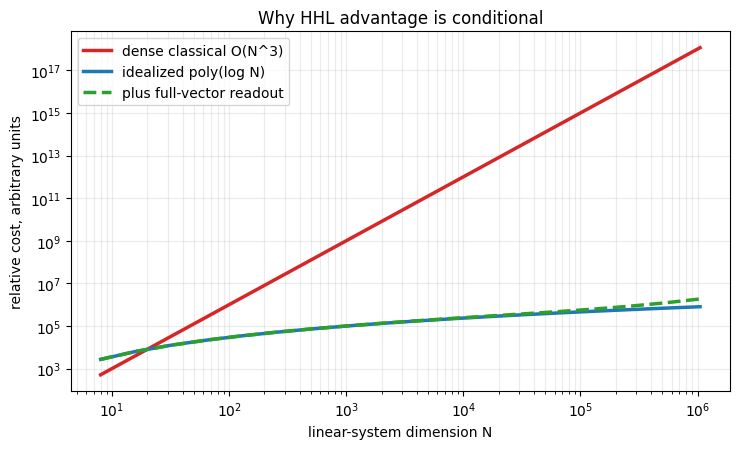

In [4]:
# Pseudo-code:
#   1. create increasing linear-system sizes
#   2. compare dense solve and idealized HHL scaling
#   3. include full-vector readout cost
#   4. plot conceptual complexity curves

# Conceptual scaling plot: dense classical solve versus idealized HHL-like curve.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

N = 2 ** np.arange(3, 21)
dense_solve = N.astype(float) ** 3
hhl_like = (np.log2(N) ** 3) * 100.0
readout_all_entries = hhl_like + N

plt.figure(figsize=(7.5, 4.6))
plt.loglog(N, dense_solve, color="tab:red", linewidth=2.5, label="dense classical O(N^3)")
plt.loglog(N, hhl_like, color="tab:blue", linewidth=2.5, label="idealized poly(log N)")
plt.loglog(N, readout_all_entries, color="tab:green", linewidth=2.5, linestyle="--", label="plus full-vector readout")
plt.title("Why HHL advantage is conditional")
plt.xlabel("linear-system dimension N")
plt.ylabel("relative cost, arbitrary units")
plt.grid(alpha=0.25, which="both")
plt.legend()
plt.tight_layout()
plt.show()


## Summary

HHL is not a drop-in replacement for `np.linalg.solve`. It is a state-preparation algorithm for linear systems.

In QML, it becomes relevant when the learning problem can be written as a linear system, such as

$$
(K+\lambda I)\alpha = y,
$$

and when the task only needs a compressed property of the solution state. The potential advantage depends on efficient state preparation, sparse or block-encoded matrices, good conditioning, limited readout, and enough precision for the downstream prediction.
